In [265]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [266]:
df = pd.read_csv('WineQT.csv')

In [267]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [268]:
df = df.drop(columns=['Id'])

In [269]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [270]:
df.shape

(1143, 12)

In [271]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [272]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


<Axes: >

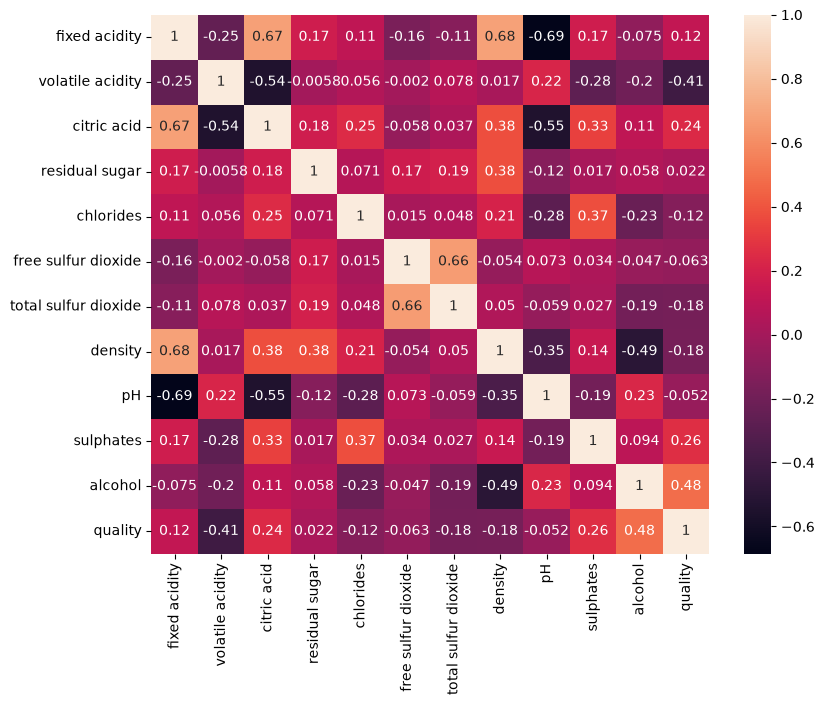

In [273]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(numeric_only=True),annot = True)

In [274]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [275]:
selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol']

In [276]:
for q in df['quality']:
    if q>5:
        df['quality'] = df['quality'].replace(q,1)
    else:
        df['quality'] = df['quality'].replace(q,0)


In [277]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [278]:
X = df[selected_features]
y = df["quality"]

In [279]:
def train_test_split(X, y, test_size=0.33, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    indices = np.random.permutation(len(X))

    test_count = int(len(X) * test_size)

    test_indices = indices[:test_count]
    train_indices = indices[test_count:]

    X_train = X.iloc[train_indices]
    X_test = X.iloc[test_indices]

    y_train = y.iloc[train_indices]
    y_test = y.iloc[test_indices]

    return X_train, X_test, y_train, y_test


In [280]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [281]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

In [282]:
X_mean = np.mean(X_train_np, axis=0)
X_std = np.std(X_train_np, axis=0)
print("X_mean = ", X_mean)
print("X_std = ", X_std)

X_mean =  [ 8.26174863  0.53095628  0.26594536  0.08648087 45.81912568  0.99668311
  0.65563934 10.43874317]
X_std =  [1.69809318e+00 1.78860963e-01 1.94818838e-01 4.73849070e-02
 3.18999343e+01 1.91233860e-03 1.65964316e-01 1.07368431e+00]


In [283]:
X_train_scaled = (X_train_np - X_mean) / X_std
X_test_scaled = (X_test_np - X_mean) / X_std

In [284]:
def sigmoid(z):
    g = 1 / (1+np.exp(-z))
    
    return g

In [285]:
def compute_cost(X, y, w, b, lambda_=1):
    m = X.shape[0]
    z = np.dot(X, w) + b
    g = sigmoid(z)
    
    epsilon = 1e-15 
    temp_cost = -np.mean(y * np.log(g + epsilon) + (1 - y) * np.log(1 - g + epsilon))

    reg_cost = (lambda_ / (2 * m)) * np.sum(w**2)
    
    return temp_cost + reg_cost

In [286]:
def compute_gradient(X, y, w, b, lambda_=1): 
    m = X.shape[0]
    z = np.dot(X, w) + b
    g = sigmoid(z)
    
    err = g - y
    dj_db = np.sum(err) / m
    dj_dw = np.dot(X.T, err) / m + (lambda_ / m) * w
        
    return dj_db, dj_dw

In [287]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    m = len(X)

    J_history = []
    w_history = []
    
    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)   
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        if i<100000:
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            # print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history

In [288]:
def train_model(X_train, y_train, alpha=0.01, num_iters=1000, lambda_=1):
    m, n = X_train.shape
    w_in = np.zeros(n)
    b_in = 0.0
    
    w_final, b_final, J_history, w_history = gradient_descent(
        X_train, y_train, 
        w_in, b_in, 
        compute_cost, compute_gradient, 
        alpha, num_iters, lambda_
    )
    
    return w_final, b_final

In [289]:
def predict_model(X_test, w_final, b_final):
    z = np.dot(X_test, w_final) + b_final
    g = sigmoid(z)
    
    return (g >= 0.5).astype(int)

In [290]:
def check_accuracy(predictions, y_test):
    accuracy = np.mean(predictions == y_test) * 100
    return accuracy

In [291]:
w_final, b_final = train_model(X_train_scaled, y_train_np,alpha=0.5, num_iters=8000,lambda_=0.1)

In [292]:
y_pred = predict_model(X_test_scaled, w_final, b_final)

In [293]:
accuracy_score = check_accuracy(y_pred, y_test)

In [294]:
print(f"Model Accuracy: {accuracy_score:.2f}%")

Model Accuracy: 75.88%
